# M3 — set-aware conditional low-rank Gaussian copula

This notebook is self-contained. M3 retains M2's low-rank covariance family but changes how the full static entity group is represented before the factor parameters are predicted. See [Chapter 4](../../docs/scientific/04_dependence_models.md).


## Notation and distinction from M2

For forecast instance $i$, lead $\tau$, and static group $\mathcal E_g=\{k_1,\ldots,k_{K_g}\}$, let $v_{k,\tau}^{(i)}\in\mathbb R^F$ contain the FM-derived information available for entity $k$. Stacking all rows gives
$$X_{g,\tau}^{(i)}=[v_{k,\tau}^{(i)}]_{k\in\mathcal E_g}\in\mathbb R^{K_g\times F}.$$
M2 transforms each row independently before constructing dependence. M3 first applies a set encoder,
$$H_{g,\tau}^{(i)}=\operatorname{Encoder}_\theta(X_{g,\tau}^{(i)}),$$
so the representation of one entity may depend on every other entity in the complete group. A shared head then predicts a loading vector $\lambda_k\in\mathbb R^r$ and uniqueness scale $\sigma_k>0$. With $\Lambda=[\lambda_k^\mathsf T]_k$,
$$\Sigma=\Lambda\Lambda^\mathsf T+\operatorname{diag}(\sigma_1^2,\ldots,\sigma_{K_g}^2),\qquad R_{ab}=\frac{\Sigma_{ab}}{\sqrt{\Sigma_{aa}\Sigma_{bb}}}.$$


## Self-attention and permutation equivariance

For one attention head, $Q=XW_Q$, $K=XW_K$, and $B=XW_V$, giving
$$\operatorname{Attn}(X)=\operatorname{softmax}\!\left(\frac{QK^\mathsf T}{\sqrt d}\right)B.$$
Each output row is therefore a data-dependent weighted combination of value vectors from the full group. M3 uses no positional encoding or entity-ID embedding. If $P$ reorders the entities, the intended identity is
$$R(PX)=P\,R(X)P^\mathsf T.$$
Thus entity order changes only the order of the resulting matrix, not the represented physical relationship.


In [2]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import torch

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / 'pyproject.toml').is_file()
)
CACHE_ROOT = PROJECT_ROOT / 'artifacts' / 'cache'
SOURCE_ROOT = str(PROJECT_ROOT / 'src')
if SOURCE_ROOT not in sys.path:
    sys.path.insert(0, SOURCE_ROOT)

from simcast.config import load_base_config, load_method_config, resolve_run_config
from simcast.experiments import locate_compatible_cache
from simcast.fm.cache import load_pit_library
from simcast.fm.pit import dependence_pit_scores
from simcast.sampling.gaussian_copula import generate_scenarios, sample_gaussian_uniforms
from simcast.training.checkpoint import load_conditional_checkpoint
from simcast.cli.train_dependence import train_from_config
from simcast.cli.evaluate import evaluate_from_config

BASE_FILE = 'configs/bases/liander2024/solar_park.yaml'
METHOD_FILE = 'configs/methods/m3_set_aware_low_rank.yaml'
BASE_OVERRIDES = (f'output.cache_dir={CACHE_ROOT}',)
METHOD_OVERRIDES = ()
FIT_IF_MISSING = True
RUN_EVALUATION = True
VISUALIZE_FITTED_MODEL = True
RUN_DIR = PROJECT_ROOT / 'runs' / 'notebook_walkthrough' / 'm3_set_aware'

base = load_base_config(PROJECT_ROOT / BASE_FILE, overrides=BASE_OVERRIDES)
method = load_method_config(PROJECT_ROOT / METHOD_FILE, overrides=METHOD_OVERRIDES)
config = resolve_run_config(base, method)
cache_dir = locate_compatible_cache(base)
library = load_pit_library(cache_dir, access='training')
ds = library.dataset
entity_ids = [str(value) for value in ds.entity_id.values]
K_g = len(entity_ids)
s = method.model
print({'g': base.data.entity_type, 'K_g': K_g, 'layers': s.num_layers,
       'heads': s.num_heads, 'rank': s.latent_rank})


{'g': 'solar_park', 'K_g': 5, 'layers': 2, 'heads': 4, 'rank': 4}


## Attention as contextual weighting

The matrix below is a synthetic illustration, not a learned result. Entry $(a,b)$ is the fraction of entity $a$'s contextual update drawn from entity $b$ in one hypothetical attention head, and every row sums to one. Actual M3 uses multiple heads and layers. Attention weights are intermediate transformations; they are not correlations. The final factor parameters determine $R$.


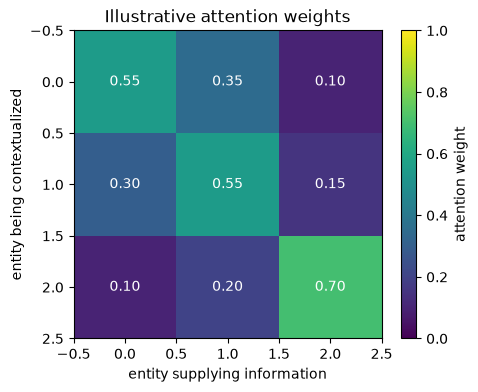

In [3]:
weights = np.array([
    [0.55, 0.35, 0.10],
    [0.30, 0.55, 0.15],
    [0.10, 0.20, 0.70],
])
fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(weights, vmin=0, vmax=1, cmap='viridis')
for row in range(3):
    for column in range(3):
        ax.text(column, row, f'{weights[row, column]:.2f}',
                ha='center', va='center', color='white')
ax.set(title='Illustrative attention weights',
       xlabel='entity supplying information',
       ylabel='entity being contextualized')
fig.colorbar(image, ax=ax, label='attention weight')
plt.show()


## Estimation

For each complete Gaussianized score vector $\mathbf z_{g,\tau}^{(i)}$, M3 minimizes
$$\mathcal L=\tfrac12\left[\log|R|+\mathbf z^\mathsf T(R^{-1}-I)\mathbf z\right].$$
The chronological training partition estimates the network parameters; chronological validation pseudo-negative log-likelihood selects the checkpoint. The following cell calls the same fitting and evaluation functions as the command-line workflow and remains inert unless its control flags are enabled.


In [4]:
if FIT_IF_MISSING and not (RUN_DIR / 'best.pt').is_file():
    train_from_config(config, cache_dir=cache_dir, output_dir=RUN_DIR)
if RUN_EVALUATION:
    evaluate_from_config(
        config,
        methods=('set_aware_low_rank',),
        method_runs={'set_aware_low_rank': RUN_DIR},
        cache_dir=cache_dir,
        output_dir=RUN_DIR / 'evaluation',
    )


## Conditional correlation across information states

A fitted M3 checkpoint maps each complete information state $X_{g,\tau}^{(i)}$ to $R_{g,\tau}^{(i)}$. The first two panels compare two cached states. The third shows the signed difference $R_{g,\tau_b}^{(i_b)}-R_{g,\tau_a}^{(i_a)}$; positive cells indicate stronger predicted correlation in the second state.

The computation requires `RUN_DIR/best.pt`. If it is absent, point `RUN_DIR` to a compatible fitted M3 run or explicitly enable `FIT_IF_MISSING`. An untrained network is never presented as a scientific result.


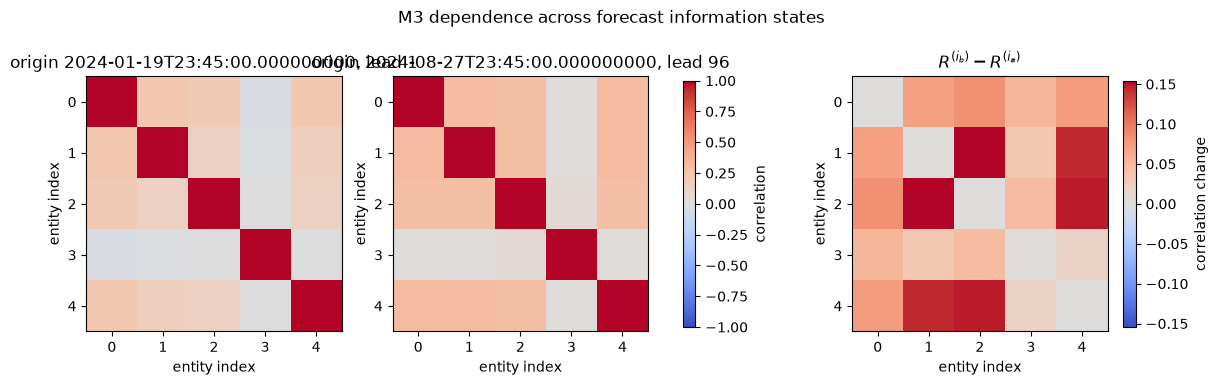

In [5]:
checkpoint_path = RUN_DIR / 'best.pt'
m3_visuals_ready = VISUALIZE_FITTED_MODEL and checkpoint_path.is_file()

if m3_visuals_ready:
    checkpoint = load_conditional_checkpoint(checkpoint_path)
    if checkpoint.method != 'set_aware_low_rank':
        raise ValueError('The selected checkpoint is not an M3 model.')
    if checkpoint.entity_ids != tuple(entity_ids):
        raise ValueError('The checkpoint entity order does not match the cache.')

    training = np.asarray(ds['split'].values) == 'train'
    valid = training[:, None] & np.asarray(ds['pit_valid'].values, dtype=bool)
    candidates = np.argwhere(valid)
    if len(candidates) == 0:
        raise ValueError('No complete training case is available for visualization.')

    positions = np.linspace(0, len(candidates) - 1, min(2, len(candidates)), dtype=int)
    selected = candidates[np.unique(positions)]
    levels = torch.tensor(np.asarray(ds['quantile'].values).copy(), dtype=torch.float32)
    locations = None
    if 'latitude' in ds and 'longitude' in ds:
        coordinates = np.stack((ds['latitude'].values, ds['longitude'].values), axis=-1)
        locations = torch.tensor(coordinates.copy(), dtype=torch.float32)

    matrices = []
    case_features = []
    with torch.no_grad():
        for origin_index, lead_index in selected:
            embeddings = torch.tensor(
                np.asarray(ds['forecast_embedding'].values[origin_index:origin_index + 1]).copy(),
                dtype=torch.float32,
            )
            predictions = torch.tensor(
                np.asarray(ds['quantile_prediction'].values[origin_index:origin_index + 1]).copy(),
                dtype=torch.float32,
            )
            features = checkpoint.feature_builder.transform(
                embeddings, predictions, levels, locations
            )[0, :, lead_index]
            case_features.append(features)
            matrices.append(checkpoint.model(features).numpy())

    if len(matrices) == 1:
        matrices.append(matrices[0].copy())
        selected = np.vstack((selected, selected))

    difference = matrices[1] - matrices[0]
    difference_limit = max(float(np.abs(difference).max()), 1e-6)
    labels = [
        f'origin {ds.origin_timestamp.values[i]}, lead {int(ds.lead.values[tau])}'
        for i, tau in selected
    ]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, matrix, label in zip(axes[:2], matrices, labels):
        image = ax.imshow(matrix, vmin=-1, vmax=1, cmap='coolwarm')
        ax.set(title=label, xlabel='entity index', ylabel='entity index')
    difference_image = axes[2].imshow(
        difference, vmin=-difference_limit, vmax=difference_limit, cmap='coolwarm'
    )
    axes[2].set(title=r'$R^{(i_b)}-R^{(i_a)}$',
                xlabel='entity index', ylabel='entity index')
    fig.colorbar(image, ax=axes[:2], label='correlation', shrink=0.8)
    fig.colorbar(difference_image, ax=axes[2], label='correlation change', shrink=0.8)
    fig.suptitle('M3 dependence across forecast information states')
    plt.show()
else:
    print(f'No fitted M3 checkpoint at {checkpoint_path}.')


## What the set encoder changes

For the first selected state, the left panel shows pairwise cosine similarities after the entity-wise input projection but before self-attention. The right panel shows the same similarities after the full set encoder. Their difference demonstrates contextualization: each entity representation has incorporated information from the other entities. These similarities are diagnostic representations, not the final copula correlations.

The printed equivariance error independently reorders the full group and checks $R(PX)=PR(X)P^\mathsf T$. Numerical error near zero confirms that entity ordering has no scientific effect.


In [ ]:
if m3_visuals_ready:
    features = case_features[0]
    with torch.no_grad():
        projected = checkpoint.model.input_projection(features)
        contextual = checkpoint.model.set_encoder(projected.unsqueeze(0)).squeeze(0)

    projected_unit = torch.nn.functional.normalize(projected, dim=-1)
    contextual_unit = torch.nn.functional.normalize(contextual, dim=-1)
    similarities = (
        projected_unit @ projected_unit.T,
        contextual_unit @ contextual_unit.T,
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, matrix, title in zip(
        axes, similarities, ('Before set encoder', 'After set encoder')
    ):
        image = ax.imshow(matrix.numpy(), vmin=-1, vmax=1, cmap='coolwarm')
        ax.set(title=title, xlabel='entity index', ylabel='entity index')
    fig.colorbar(image, ax=axes, label='cosine similarity', shrink=0.8)
    fig.suptitle('M3 contextualizes entity representations using the full group')
    plt.show()

    permutation = torch.arange(K_g - 1, -1, -1)
    with torch.no_grad():
        permuted_R = checkpoint.model(features[permutation])
    expected_R = torch.tensor(matrices[0])[permutation][:, permutation]
    equivariance_error = float((permuted_R - expected_R).abs().max())
    print({'maximum permutation-equivariance error': equivariance_error})
else:
    print('A fitted M3 checkpoint is required for contextualization diagnostics.')


## Factor decomposition of one conditional matrix

After contextualization, M3 predicts one loading vector $\lambda_k$ and one uniqueness scale $\sigma_k$ for each entity. The panels display the resulting $\Lambda$ and $\sigma$. Factor columns are rotation-dependent and should not be interpreted as uniquely identified physical mechanisms.


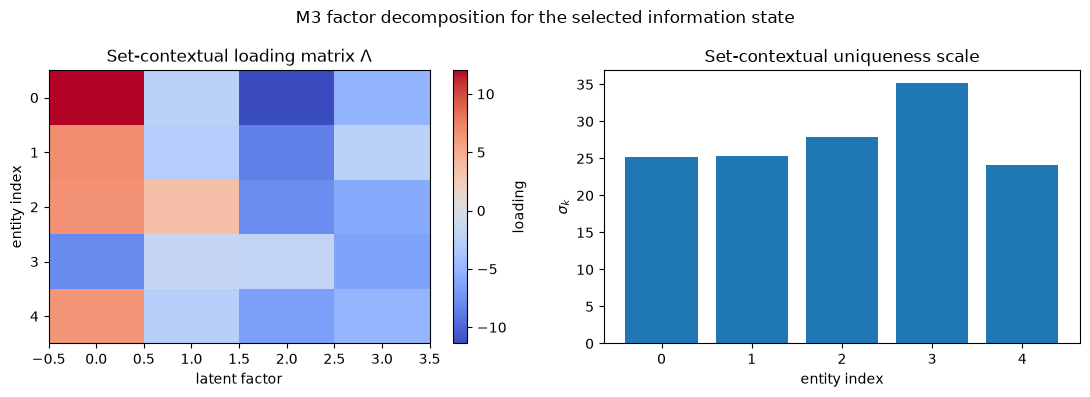

In [6]:
if m3_visuals_ready:
    with torch.no_grad():
        loadings, sigma = checkpoint.model.factor_parameters(case_features[0])

    fig, (ax_loadings, ax_sigma) = plt.subplots(1, 2, figsize=(11, 4))
    image = ax_loadings.imshow(loadings.numpy(), aspect='auto', cmap='coolwarm')
    ax_loadings.set(xlabel='latent factor', ylabel='entity index',
                    title=r'Set-contextual loading matrix $\Lambda$')
    fig.colorbar(image, ax=ax_loadings, label='loading')
    ax_sigma.bar(np.arange(K_g), sigma.numpy())
    ax_sigma.set(xlabel='entity index', ylabel=r'$\sigma_k$',
                 title='Set-contextual uniqueness scale')
    fig.suptitle('M3 factor decomposition for the selected information state')
    plt.tight_layout()
    plt.show()
else:
    print('A fitted M3 checkpoint is required for the factor decomposition.')


## Historical scores and one conditional Gaussian law

The left panel shows complete historical training scores at the selected lead, pooled across forecast origins. The right panel shows draws from $\mathcal N(\mathbf0,R_{g,\tau}^{(i)})$ for the first selected state. The displayed pair has the largest absolute off-diagonal correlation in that conditional matrix. Since one panel mixes information states and the other conditions on one state, this is a mechanism visualization rather than an out-of-sample calibration assessment.


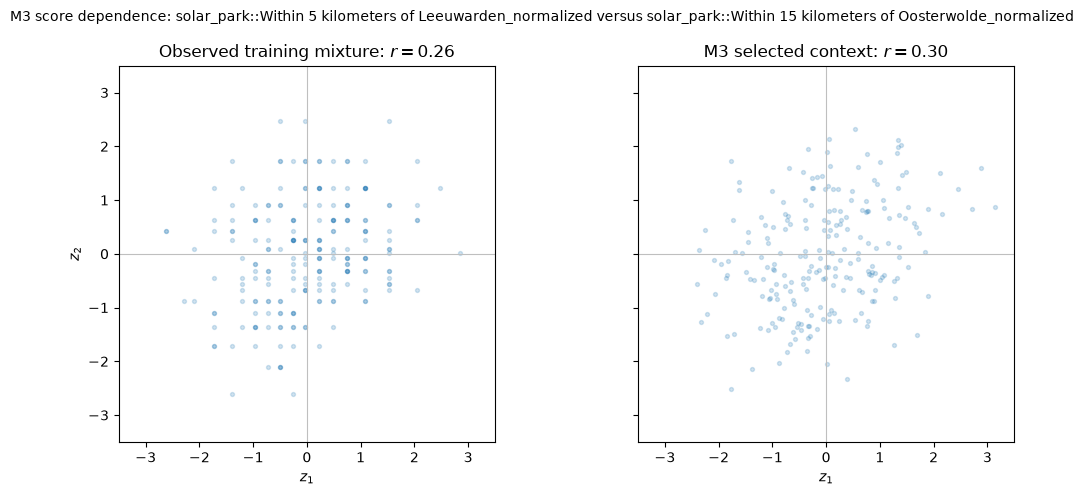

In [7]:
if m3_visuals_ready:
    origin_index, lead_index = map(int, selected[0])
    R_fitted = matrices[0]
    strength = np.abs(R_fitted.copy())
    np.fill_diagonal(strength, -np.inf)
    entity_a, entity_b = np.unravel_index(np.argmax(strength), strength.shape)

    scores, _ = dependence_pit_scores(
        torch.tensor(np.asarray(ds['pit_u'].values).copy()),
        torch.tensor(np.asarray(ds['pit_z'].values).copy()),
        torch.tensor(training.copy()), levels,
        mode=config.pit.dependence_transform, eps=config.pit.eps,
    )
    observed = scores.numpy()[training, :, lead_index]
    observed = observed[np.isfinite(observed).all(axis=1)]

    generator = torch.Generator().manual_seed(config.sampling.evaluation_seed)
    fitted_u = sample_gaussian_uniforms(
        torch.tensor(R_fitted, dtype=torch.float32), len(observed), generator=generator
    )
    fitted_z = torch.special.ndtri(fitted_u).numpy()
    step = max(1, len(observed) // 5000)
    observed_pair = observed[::step][:, [entity_a, entity_b]]
    fitted_pair = fitted_z[::step][:, [entity_a, entity_b]]
    limit = max(3.5, np.nanpercentile(
        np.abs(np.vstack((observed_pair, fitted_pair))), 99.5
    ))

    observed_r = np.corrcoef(observed, rowvar=False)[entity_a, entity_b]
    fitted_r = np.corrcoef(fitted_z, rowvar=False)[entity_a, entity_b]
    panels = (
        (observed_pair, fr'Observed training mixture: $r={observed_r:.2f}$'),
        (fitted_pair, fr'M3 selected context: $r={fitted_r:.2f}$'),
    )
    fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
    for ax, (points, title) in zip(axes, panels):
        ax.scatter(points[:, 0], points[:, 1], s=8, alpha=0.2)
        ax.axhline(0, color='0.75', lw=0.8)
        ax.axvline(0, color='0.75', lw=0.8)
        ax.set(xlim=(-limit, limit), ylim=(-limit, limit), aspect='equal',
               xlabel=fr'$z_{{{entity_a + 1}}}$', title=title)
    axes[0].set_ylabel(fr'$z_{{{entity_b + 1}}}$')
    fig.suptitle(
        f'M3 score dependence: {entity_ids[entity_a]} versus {entity_ids[entity_b]}',
        fontsize=10,
    )
    plt.tight_layout()
    plt.show()
else:
    print('A fitted M3 checkpoint is required for the score-space comparison.')


## From conditional ranks to entity and aggregate scenarios

For the same state, M3 draws $X^{(m)}\sim\mathcal N(\mathbf0,R_{g,\tau}^{(i)})$ and maps it to $U_k^{(m)}=\Phi(X_k^{(m)})$. Projection through the fixed marginal forecast gives $\widetilde Y_{k,\tau}^{(i,m)}=(\widehat F_{k,\tau}^{(i)})^{-1}(U_k^{(m)})$, followed by $\widetilde A_{g,\tau}^{(i,m)}=\sum_k\widetilde Y_{k,\tau}^{(i,m)}$. The panels trace the same Monte Carlo draws through probability, entity, and aggregate space.


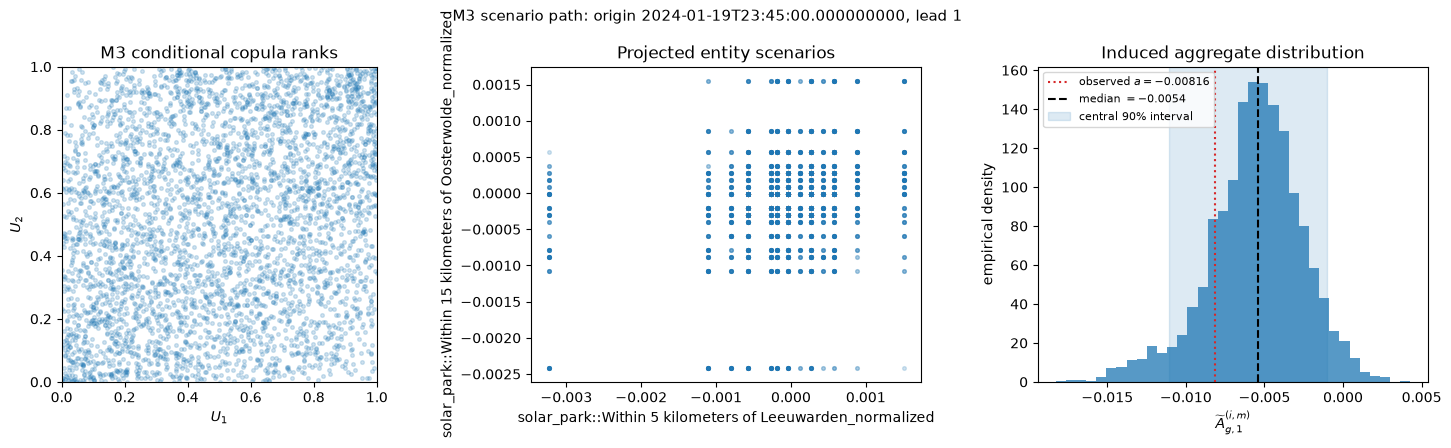

In [8]:
if m3_visuals_ready:
    qhat = torch.tensor(
        np.asarray(ds['quantile_prediction'].values[origin_index, :, lead_index]).copy(),
        dtype=torch.float32,
    )
    generator = torch.Generator().manual_seed(config.sampling.evaluation_seed)
    scenarios = generate_scenarios(
        torch.tensor(R_fitted, dtype=torch.float32), qhat, levels,
        num_samples=config.sampling.num_samples,
        generator=generator, marginal_mode=config.pit.mode,
    )
    u = scenarios.uniforms.numpy()
    y = scenarios.entity_samples.numpy()
    aggregate = scenarios.aggregate_samples.numpy()
    observed = float(ds['true_y'].values[origin_index, :, lead_index].sum())
    q05, median, q95 = np.quantile(aggregate, [0.05, 0.5, 0.95])
    lead = int(ds['lead'].values[lead_index])
    origin = ds['origin_timestamp'].values[origin_index]

    fig, (ax_u, ax_y, ax_a) = plt.subplots(1, 3, figsize=(15, 4.5))
    ax_u.scatter(u[:, entity_a], u[:, entity_b], s=7, alpha=0.2)
    ax_u.set(xlim=(0, 1), ylim=(0, 1), aspect='equal',
             xlabel=fr'$U_{{{entity_a + 1}}}$', ylabel=fr'$U_{{{entity_b + 1}}}$',
             title='M3 conditional copula ranks')
    ax_y.scatter(y[:, entity_a], y[:, entity_b], s=7, alpha=0.2)
    ax_y.set(xlabel=entity_ids[entity_a], ylabel=entity_ids[entity_b],
             title='Projected entity scenarios')
    ax_a.hist(aggregate, bins=35, density=True, alpha=0.75)
    ax_a.axvline(observed, color='C3', ls=':', label=fr'observed $a={observed:.3g}$')
    ax_a.axvline(median, color='black', ls='--', label=fr'median $={median:.3g}$')
    ax_a.axvspan(q05, q95, color='C0', alpha=0.15, label='central 90% interval')
    ax_a.set(xlabel=fr'$\widetilde A_{{g,{lead}}}^{{(i,m)}}$',
             ylabel='empirical density', title='Induced aggregate distribution')
    ax_a.legend(fontsize=8)
    fig.suptitle(f'M3 scenario path: origin {origin}, lead {lead}', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print('A fitted M3 checkpoint is required for scenario propagation.')


## Controls and interpretation

`method.features.*` defines $X$. `method.model.model_dim`, `num_layers`, `num_heads`, `latent_rank`, `dropout`, `sigma_floor`, and `jitter` define the set-aware low-rank map. `method.optimization.*` controls estimation. `SetAwareLowRankGaussianCopula` implements M3. A gain over M2 isolates the empirical value of full-group contextualization within the shared low-rank family; failure to gain does not imply absence of dependence.
